In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import cvxpy as cp
import statsmodels.api as sm
import missingno as msno
from pandas_datareader import data as pdr
from scipy.linalg import sqrtm


In [2]:
start = "2005-01-01"
end = "2026-01-01"

tickers = [
    "VTI",  # Vanguard Total Stock Market (Mercado total EE.UU.)
    "QQQ",  # Invesco QQQ Trust (Tecnología Nasdaq 100)
    "BTC-USD",  # Bitcoin (Activo de riesgo/liquidez global)
    "ASML",  # ASML Holding (Semiconductores, ciclo de innovación)
    "XWD.TO",  # iShares MSCI World ETF (Renta variable global)
    "GLD",  # SPDR Gold Shares  (Oro, refugio de valor)
    "USO",  # United States Oil Fund, LP (Petróleo, energía)
    "AGZD",  # WisdomTree Interest Rate Hedged U.S. Aggregate Bond Fund (Cobertura de tipos)
    "DBA",  # Invesco DB Agriculture Fund (Materias primas agrícolas)
    "VNQ",  # Vanguard Real Estate Index Fund ETF Shares (Bienes raíces)
    "SH",  # ProShares Short S&P500 (Inverso del mercado)
    "VXX",  # iPath Series B S&P 500 VIX Short-Term Futures ETN (Volatilidad/Miedo)
    "TLT",  # iShares 20+ Year Treasury Bond ETF (Bonos largo plazo)
    "PSQ",
        "BA",
    "BAX",
    "BMY",
    "CMCSA",
    "CNP",
    "CPB",
    "DE",
    "F",
    "GE",
    "HPQ",
    "JCI",
    "JPM",
    "KHC",
    "LUV",
    "MO",
    "NI",
    "PCAR",
    "PSA",
    "SEE",
    "T",
    "TGT",
    "TMO",
    "TXT",
    "VZ",
    "ZION",
# ProShares Short QQQ (Inverso de tecnología)
]

data = yf.download(tickers, start, end, multi_level_index= False)["Close"]
data_idx = yf.download("SPY", start,end, multi_level_index=False)["Close"]

/tmp/ipykernel_1635/123497303.py:47: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start, end, multi_level_index= False)["Close"]
[*********************100%***********************]  39 of 39 completed
/tmp/ipykernel_1635/123497303.py:48: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_idx = yf.download("SPY", start,end, multi_level_index=False)["Close"]
[*********************100%***********************]  1 of 1 completed


In [ ]:
#Forma alternativa csv

df = pd.read_excel("mi_archivo.xlsx / .csv", index_col = 0, delimeter = "el que sea", parse_dta = True)

activos = [
    "ES0160994002",
    "IE00B42W3S00",
    "IE00BZ4D7648",
    "IE000U9ODG19",
    "LU0261948904",
    "LU0996179007",
    "LU1213836080",
]
# Carpeta donde se encuentran los ficheros.
root_path = "https://raw.githubusercontent.com/alfonso-santos/microcredencial-carteras-python/refs/heads/Feb-2025/Tema_2_Carteras_Intro/data/"
# Creamos una lista para almacenar todos los DF.
df_list = []
# Leemos los ficheros y creamos los DF.
for file_name in activos:
    df = pd.read_csv(root_path + file_name + ".csv", delimiter=";")
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.set_index("Date")
    df_list.append(df)
# Combinamos todos los DF en uno solo.
data = pd.concat(df_list, axis=1)
# Renombramos las columnas.
data.columns = activos



<Axes: >

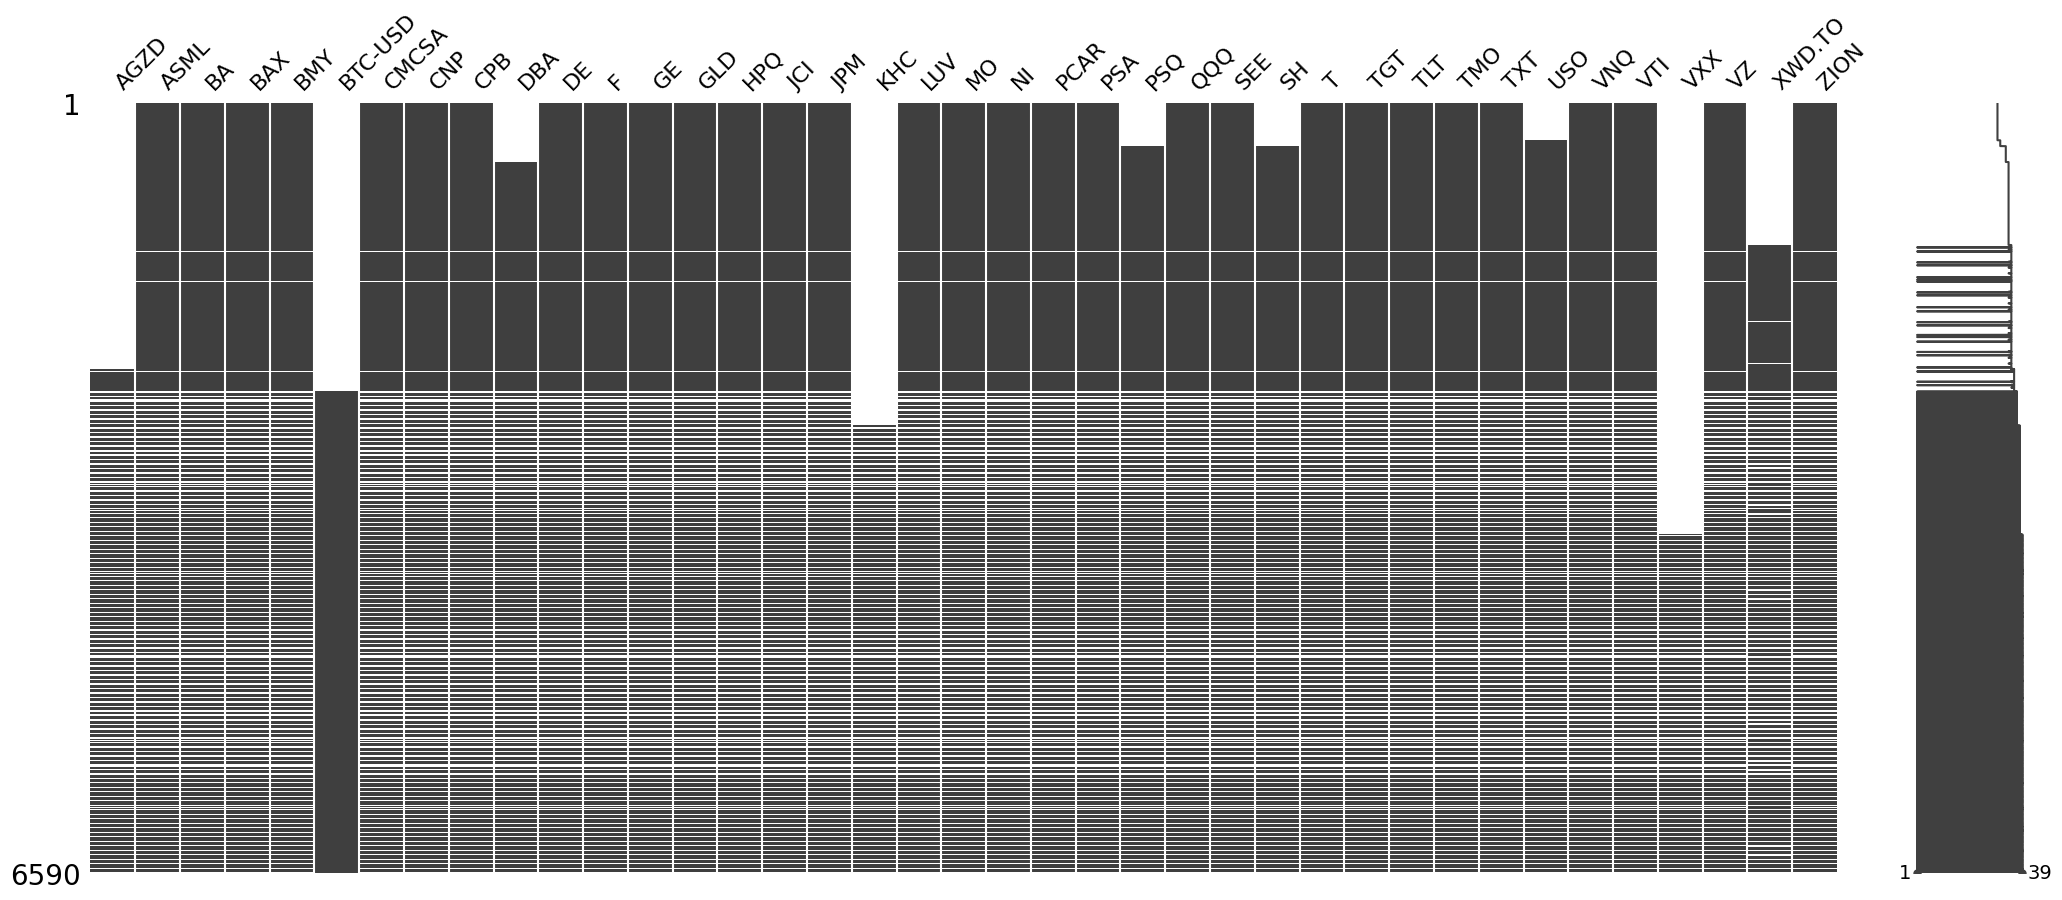

In [5]:
msno.matrix(data)

In [6]:
data = data.dropna(axis = 1, how = "all")
data = data.dropna(axis = 0, how = "any")


In [7]:
rf = 0.02

<Axes: >

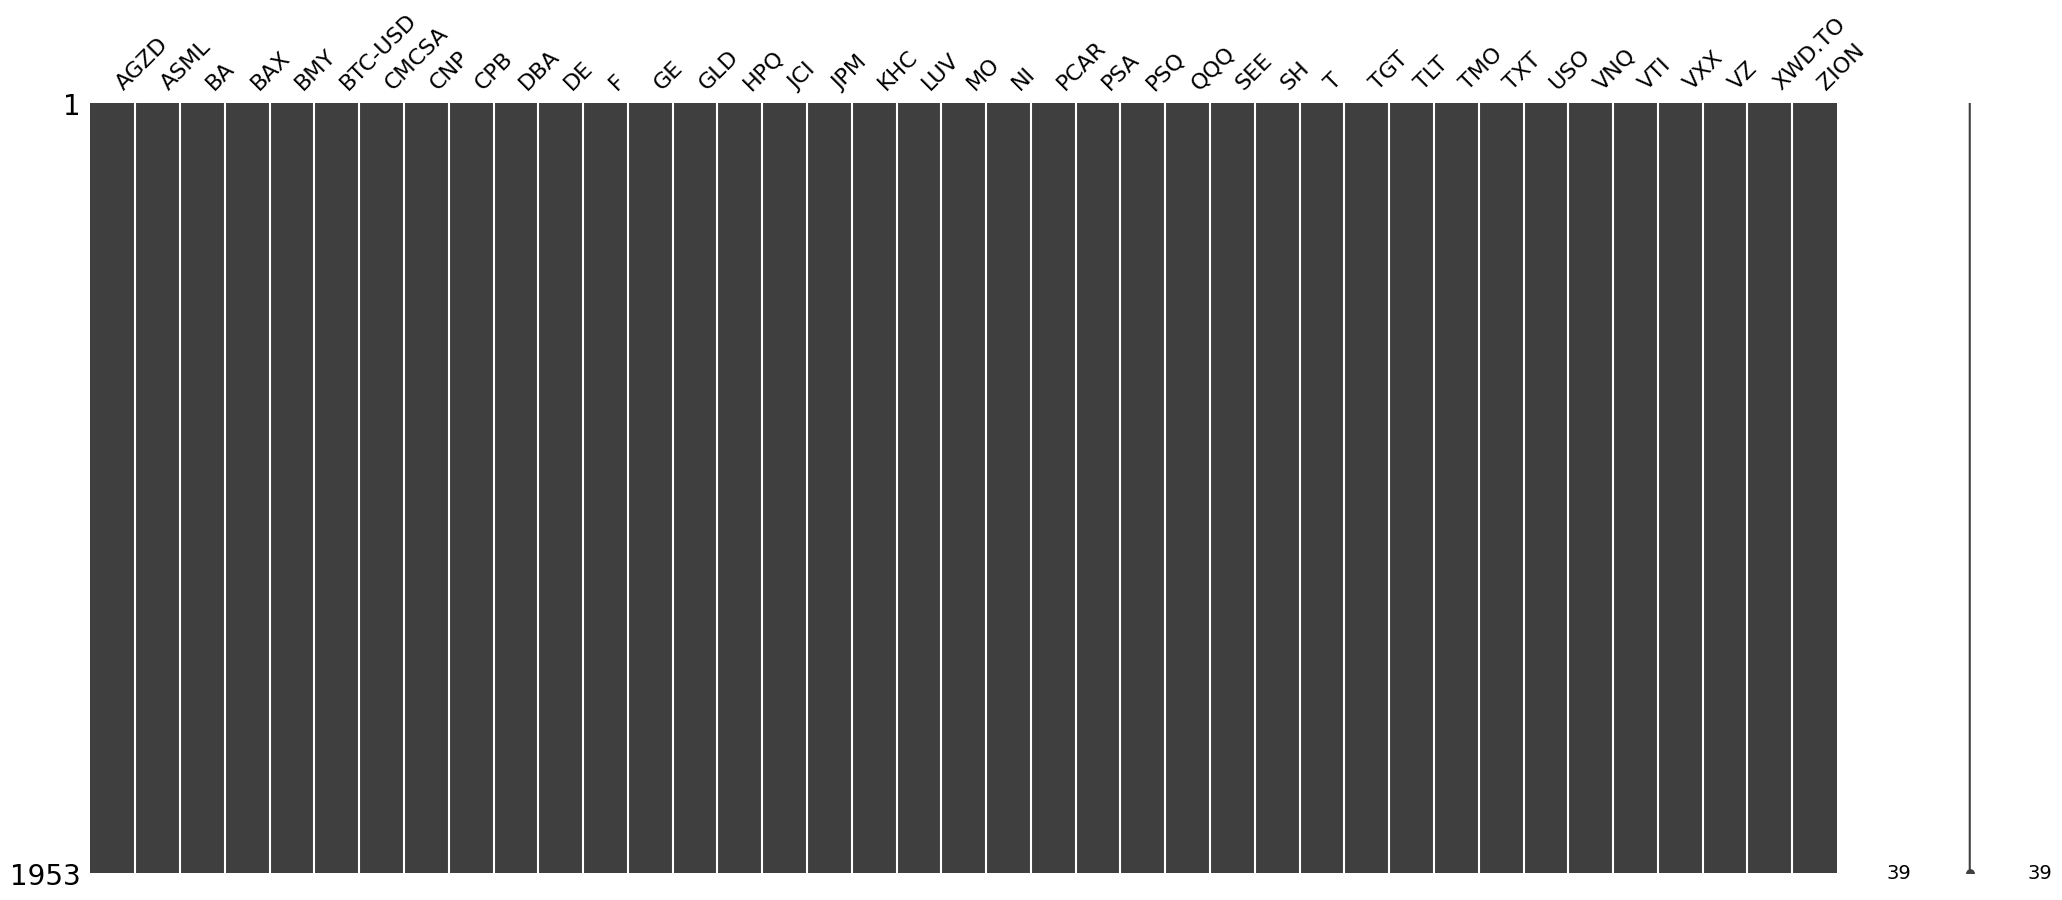

In [8]:
msno.matrix(data)

In [9]:
ret_data = np.log(data).diff().dropna()
ret_idx = np.log(data).diff().dropna()

In [10]:
def cartera_min_vol(ret):
    """Función que calcula la cartera de mínima varianza para un DataFrame de rendimientos
    ret: DataFrame de rendimientos
    Retorna pesos_ajustados: Array con los pesos de la cartera de mínima varianza"""

    if isinstance(ret, pd.DataFrame):  # Verifico que el argumento sea un DataFrame
        num_act = ret.shape[1]
        matriz_cov = ret.cov().to_numpy()

        # Variables de decisión
        pesos = cp.Variable(num_act)

        # Restricciones
        constraints = [
            pesos >= 0,
            cp.sum(pesos) == 1,
        ]

        riesgo = cp.quad_form(pesos, matriz_cov)  # Riesgo de la cartera
        objective = cp.Minimize(riesgo)  # Minimizar la varianza

        # Problema y resuelvo
        prob = cp.Problem(objective, constraints)
        resultado = prob.solve()

        pesos_ajustados = np.array(
            [np.round(x, 3) if x > 10**-4 else 0 for x in pesos.value]
        )  # Pongo a cero los pesos menores a 10^-4 y redondeo a 3 decimales

        return pesos_ajustados

    else:
        raise ValueError(
            "La función cartera_min_vol solo acepta un DataFrame como argumento"
        )  # Si el argumento no es un DataFrame, lanzo un error



In [11]:
def cartera_max_sharpe(ret, ret_rf = rf):
    """Función que calcula la cartera de máximo índice de Sharpe para un DataFrame de rendimientos
    ret: DataFrame de rendimientos
    ret_rf: Rendimiento del activo libre de riesgo
    Retorna pesos_ajustados: Array con los pesos de la cartera de máximo índice de Sharpe"""
    ret_rf = ret_rf / 252

    if isinstance(ret, pd.DataFrame):
        num_act = ret.shape[1]
        matriz_cov = ret.cov().to_numpy()
        retornos_esperados = ret.mean()

        # Variable de decisión (pesos del portafolio)
        x = cp.Variable(num_act)
        # Riesgo (desviación estándar) del portafolio
        riesgo = cp.quad_form(x, matriz_cov)

        # Cálculo de pi como retornos esperados menos la rantabilidad del activo libre de riesgo
        pi = np.array(retornos_esperados - ret_rf)

        # Restricciones
        constraints = [
            pi @ x == 1,  # para que el numerador sea 1
            x >= 0,
        ]  # sin posiciones cortas

        objective = cp.Minimize(riesgo)  # Minimizo el riesgo

        # Problema de optimización
        problema = cp.Problem(objective, constraints)

        # Resolver el problema
        resultado = problema.solve()

        # Normalizo los pesos
        pesos = x.value
        pesos /= pesos.sum()

        pesos_ajustados = np.array([np.round(x, 3) if x > 10**-4 else 0 for x in pesos])

        return pesos_ajustados

    else:
        raise ValueError("La función cartera_max_sharpe solo acepta un DataFrame como argumento")

In [12]:
def cartera_risk_parity(ret):
    """
    Función que calcula la cartera de riesgo paridad para un DataFrame de rendimientos
    ret: DataFrame de rendimientos
    Retorna pesos_ajustados: Array con los pesos de la cartera de riesgo paridad"""

    if isinstance(ret, pd.DataFrame):
        num_act = ret.shape[1]
        matriz_cov = ret.cov().to_numpy()
        retornos_esperados = ret.mean().to_numpy()

        b = 1 / num_act

        x = cp.Variable(num_act)
        gamma = cp.Variable(num_act, nonneg=True)
        psi = cp.Variable(nonneg=True)

        z = matriz_cov @ x

        obj = cp.pnorm(b**0.5 * psi - gamma, p=2)
        ret = retornos_esperados.T @ x

        constraints = [cp.sum(x) == 1, x >= 0, cp.SOC(psi, sqrtm(matriz_cov) @ x)]

        for i in range(num_act):
            constraints += [cp.SOC(x[i] + z[i], cp.vstack([2 * gamma[i], x[i] - z[i]]))]

        objective = cp.Minimize(obj * 1000)
        prob = cp.Problem(objective, constraints)
        prob.solve()

        pesos_ajustados = np.array([np.round(xi, 3) if xi > 10**-4 else 0 for xi in x.value])

        return pesos_ajustados

    else:
        raise ValueError("La función cartera_risk_parity solo acepta un DataFrame como argumento")

In [13]:
def cartera_min_cvar(ret, alpha=0.5):
    """Función que calcula la cartera de mínimo CVaR para un DataFrame de rendimientos
    ret: DataFrame de rendimientos
    alpha: Nivel de confianza
    Retorna pesos_ajustados: Array con los pesos de la cartera de mínimo CVaR"""

    if isinstance(ret, pd.DataFrame):  # Verifico que el argumento sea un DataFrame
        retornos = ret.to_numpy()
        retornos_esperados = ret.mean().to_numpy()

        num_data, num_act = retornos.shape  # Número de datos y número de activos

        pesos = cp.Variable(num_act)
        t = cp.Variable()  # VaR
        ui = cp.Variable(num_data)  # Exceso de pérdida con respecto al VaR

        riesgo = t + cp.sum(ui) / (alpha * num_data)  # CVaR
        retornos_cartera = retornos_esperados.T @ pesos

        restricciones = [
            -retornos @ pesos - t - ui <= 0,  # Las pérdidas son menores que VaR más el exceso de pérdida
            ui >= 0,  # Los excesos son positivos
            cp.sum(pesos) == 1,
            pesos >= 0,  # No se pueden tener posiciones cortas

        ]

        objective = cp.Minimize(riesgo)

        # Solve the problem
        prob = cp.Problem(objective, restricciones)
        cvar95_min_cvar = prob.solve()

        pesos_ajustados = np.array(
            [np.round(x, 3) if x > 10**-4 else 0 for x in pesos.value]
        )  # Pongo a cero los pesos menores a 10^-4 y redondeo a 3 decimales

        return pesos_ajustados

    else:
        raise ValueError("La función cartera_min_cvar solo acepta un DataFrame como argumento")

In [14]:
def cartera_max_drawdown(ret, alpha=0.5):

    ''' Función que calcula la cartera de máximo drawdown para un DataFrame de rendimientos
    ret: DataFrame de rendimientos
    alpha: Nivel de confianza
    Retorna pesos_ajustados: Array con los pesos de la cartera de máximo drawdown'''

    if isinstance(ret, pd.DataFrame): # Verifico que el argumento sea un DataFrame
        retornos = ret.to_numpy()
        retornos_esperados = ret.mean().to_numpy()

        num_data, num_act = retornos.shape # Número de datos y número de activos

        pesos = cp.Variable(num_act)
        t = cp.Variable()
        uj = cp.Variable(num_data)
        dj = cp.Variable(num_data+1)

        riesgo = t + cp.sum(uj)/(alpha * num_data)
        #retornos_cartera = retornos_esperados.T @ pesos

        restricciones = [dj[1:] - t - uj <= 0,
                        dj[1:] >= dj[:-1] - retornos @ pesos,
                        uj >= 0,
                        dj >= 0,
                        dj[0] == 0,
                        cp.sum(pesos) == 1,
                        pesos >= 0,
                    ]

        objective = cp.Minimize(riesgo)

        # Solve the problem
        prob = cp.Problem(objective, restricciones)
        prob.solve()

        pesos_ajustados = np.array([np.round(x, 3) if x > 10**-4 else 0  for x in pesos.value]) #Pongo a cero los pesos menores a 10^-4 y redondeo a 3 decimales

        return pesos_ajustados

    else:
        raise ValueError('La función cartera_max_drawdown solo acepta un DataFrame como argumento')

In [15]:
def cartera_equiponderada(ret):
  num_act = ret.shape[1]
  pesos = np.ones(num_act) / num_act

  return pesos


In [26]:
def analisis(ret,rf = rf):
  stats = pd.DataFrame({
    'retorno_anual' : ret.mean() * 252,
    'volatilidad'   : ret.std() * np.sqrt(252),
    'sharpe'        : (ret.mean()*252 - rf) / (ret.std()*np.sqrt(252)),
    'skewness'      : ret.skew(),
    'max_drawdown'  : ret.apply(
                          lambda s: ((1+s).cumprod() / (1+s).cumprod().cummax() - 1).min()
                      )*100,
    'CVaR_%':  (-ret[ret < ret.quantile(0.05)].mean()*100).round(2),
  }).sort_values('sharpe', ascending=False)

  print(stats.round(3))
  return stats

In [27]:
stats = analisis(ret_data)

         retorno_anual  volatilidad  sharpe  skewness  max_drawdown  CVaR_%
Ticker                                                                     
GLD              0.146        0.153   0.823    -0.333       -23.890    2.22
QQQ              0.174        0.244   0.632    -0.355       -38.495    3.67
XWD.TO           0.115        0.166   0.574    -0.550       -29.329    2.53
VTI              0.124        0.201   0.518    -0.593       -37.085    3.09
ASML             0.226        0.409   0.504    -0.365       -61.987    6.07
JCI              0.162        0.292   0.488    -0.503       -48.666    4.47
JPM              0.160        0.294   0.476    -0.055       -47.297    4.30
PCAR             0.137        0.272   0.431     0.206       -39.554    3.75
GE               0.186        0.390   0.425    -0.223       -72.460    5.75
DE               0.146        0.320   0.394    -0.404       -41.093    4.72
TMO              0.129        0.278   0.393     0.063       -47.956    4.04
BTC-USD     

In [18]:
T = len(ret_data)
for i in range(4):
    sub = ret_data.iloc[i*T//4 : (i+1)*T//4]
    ret = sub.mean().mean() * 252
    vol = sub.std().mean() * np.sqrt(252)
    sh  = (ret - rf) / vol
    print(f"Cuarto {i+1}  [{sub.index[0].date()} → {sub.index[-1].date()}]"
          f"  Ret={ret*100:.1f}%  Vol={vol*100:.1f}%  Sharpe={sh:.2f}")

Cuarto 1  [2018-01-26 → 2020-01-17]  Ret=1.3%  Vol=25.0%  Sharpe=-0.03
Cuarto 2  [2020-01-21 → 2022-01-11]  Ret=11.0%  Vol=37.3%  Sharpe=0.24
Cuarto 3  [2022-01-12 → 2024-01-05]  Ret=-5.6%  Vol=28.9%  Sharpe=-0.26
Cuarto 4  [2024-01-08 → 2025-12-31]  Ret=8.0%  Vol=27.0%  Sharpe=0.22


Correlación media: 0.186


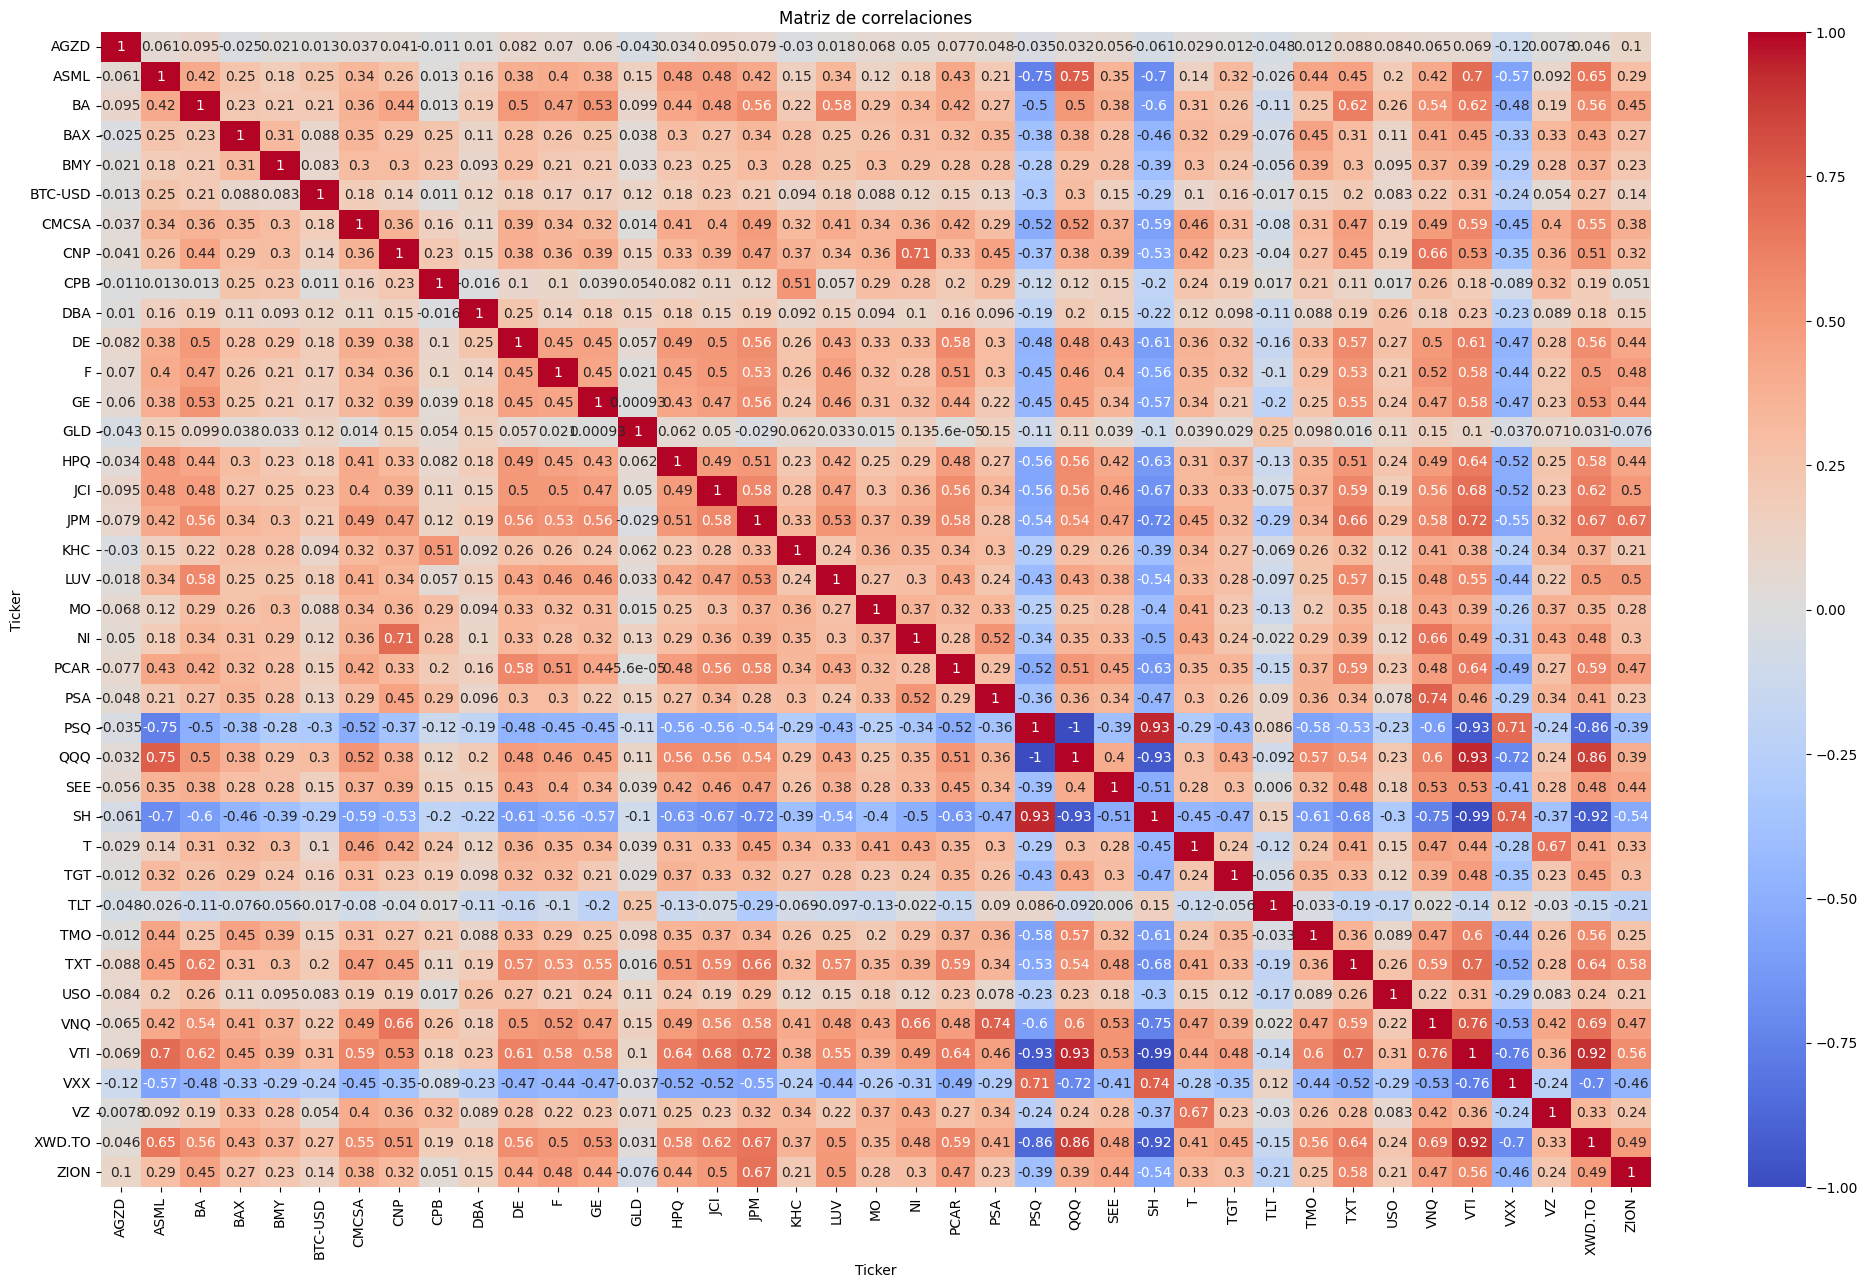

In [36]:
corr = ret_data.corr()

# Correlación media (Tema 2 del curso)
vals = corr.values.copy()
np.fill_diagonal(vals, np.nan)
print("Correlación media:", np.nanmean(vals).round(3))

# Heatmap visual
import seaborn as sns
plt.figure(figsize = (25,15))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1, annot= True)
plt.title('Matriz de correlaciones')
plt.show()

Mejor Sharpe Montecarlo: 1.0
Pesos aproximados: {'GLD': np.float64(0.594), 'QQQ': np.float64(0.009), 'XWD.TO': np.float64(0.009), 'VTI': np.float64(0.001), 'ASML': np.float64(0.002), 'JCI': np.float64(0.018), 'JPM': np.float64(0.097), 'PCAR': np.float64(0.009), 'GE': np.float64(0.012), 'DE': np.float64(0.047), 'TMO': np.float64(0.053), 'BTC-USD': np.float64(0.024), 'NI': np.float64(0.037), 'AGZD': np.float64(0.039), 'DBA': np.float64(0.049)}


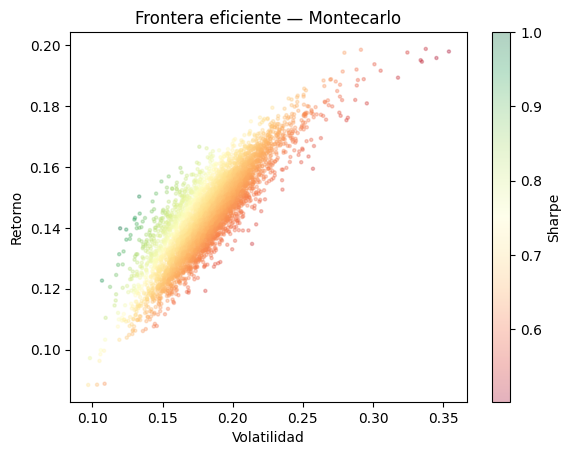

In [20]:
# Sobre los 10-15 activos preseleccionados
activos_seleccionados = stats.head(15).index.tolist()
ret_sel = ret_data[activos_seleccionados]
n = len(activos_seleccionados)

resultados = {'ret': [], 'vol': [], 'sharpe': [], 'pesos': []}

for _ in range(5000):
    w = np.random.dirichlet(np.ones(n))   # pesos aleatorios que suman 1
    r_port = ret_sel @ w
    ret_a  = r_port.mean() * 252
    vol_a  = r_port.std()  * np.sqrt(252)
    sh     = (ret_a - rf) / vol_a
    resultados['ret'].append(ret_a)
    resultados['vol'].append(vol_a)
    resultados['sharpe'].append(sh)
    resultados['pesos'].append(w)

# La cartera de mayor Sharpe entre las 5000 aleatorias
idx_mejor = np.argmax(resultados['sharpe'])
print("Mejor Sharpe Montecarlo:", round(resultados['sharpe'][idx_mejor], 3))
print("Pesos aproximados:", dict(zip(activos_seleccionados,
      resultados['pesos'][idx_mejor].round(3))))

# Visualizar frontera (Tema 3)
plt.scatter(resultados['vol'], resultados['ret'],
            c=resultados['sharpe'], cmap='RdYlGn', alpha=0.3, s=5)
plt.colorbar(label='Sharpe')
plt.xlabel('Volatilidad'); plt.ylabel('Retorno')
plt.title('Frontera eficiente — Montecarlo')
plt.show()



In [21]:
pesos_rkp = cartera_risk_parity(ret_sel)
pesos_maxsh = cartera_max_sharpe(ret_sel)
pesos_minvar = cartera_min_cvar(ret_sel)
pesos_ew = cartera_equiponderada(ret_sel)
pesos_min_vol = cartera_min_vol(ret_sel)
pesos_maxdr = cartera_max_drawdown(ret_sel)

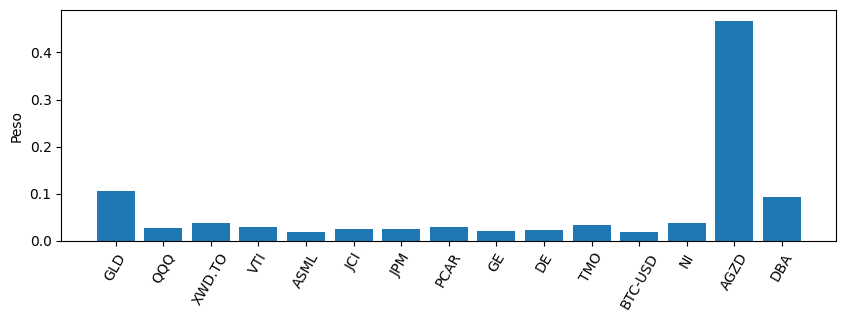

In [22]:
plt.figure(figsize=(10, 3))
num_act = ret_sel.shape[1]
plt.bar(range(num_act), pesos_rkp)
plt.xticks(range(num_act), activos_seleccionados, rotation=60)
plt.ylabel("Peso")
plt.show()

In [23]:
sharpe = (pesos_rkp.mean()*252 - rf) / (pesos_rkp.std()*np.sqrt(252))
sharpe

np.float64(9.604349022172213)

In [24]:
# Evaluar cada cartera en ventanas de 1 año
# para ver cómo respondería en distintos escenarios posibles
carteras = {
    'MaxSharpe' : pesos_maxsh,
    'MinVar'    : pesos_minvar,
    'EqualW'    : pesos_ew,
    'RiskPar'    : pesos_rkp,
    'MinVol'    : pesos_min_vol,
    'MaxDr'    : pesos_maxdr,


    'Montecarlo': resultados['pesos'][idx_mejor],
}

ventana, paso = 252, 63
filas = []
for inicio in range(0, T - ventana, paso):
    sub  = ret_sel.iloc[inicio : inicio + ventana]
    fila = {'periodo': f"{sub.index[0].date()}→{sub.index[-1].date()}"}
    for nombre, w in carteras.items():
        r  = sub @ w
        sh = (r.mean()*252 - rf) / (r.std()*np.sqrt(252))
        fila[nombre] = round(sh, 2)
    filas.append(fila)

df_bt = pd.DataFrame(filas).set_index('periodo')
print(df_bt)
print("\nSharpe MEDIO por cartera:")
print(df_bt.mean().sort_values(ascending=False).round(3))

                       MaxSharpe  MinVar  EqualW  RiskPar  MinVol  MaxDr  \
periodo                                                                    
2018-01-26→2019-02-04      -1.04   -0.52   -1.00    -0.95   -0.56  -0.34   
2018-04-27→2019-05-06      -0.24   -0.08    0.12     0.01   -0.20   0.13   
2018-07-31→2019-08-08       1.38    0.50    0.43     0.56    0.36   0.42   
2018-10-31→2019-11-07       2.07    1.06    1.44     1.53    0.93   0.87   
2019-02-05→2020-02-11       2.87    1.36    2.36     2.37    1.20   1.04   
2019-05-07→2020-05-12       0.71   -0.19   -0.12    -0.14   -0.27  -0.25   
2019-08-09→2020-08-14       1.00    0.13    0.34     0.37    0.08   0.01   
2019-11-08→2020-11-13       0.94    0.00    0.54     0.51   -0.04  -0.14   
2020-02-12→2021-02-18       0.74   -0.01    0.93     0.75    0.00  -0.13   
2020-05-13→2021-05-19       1.76    1.39    3.10     3.05    1.57   0.77   
2020-08-17→2021-08-23       0.56    0.08    2.73     2.31    0.32  -0.51   
2020-11-16→2

ANTES (sin gastar vidas):
  ├─ Análisis estadístico → conoces los 50 activos
  ├─ Análisis de régimen  → sabes si hay crisis en el dato
  ├─ Preselección 10-15   → reduces el problema
  ├─ Montecarlo 5000      → tienes una cartera buena sin optimizar
  ├─ CVXPY 3 carteras     → tienes las carteras óptimas formales
  └─ Backtesting          → sabes cuál gana en más ventanas

VIDA 1 → La ganadora del backtesting (mayor Sharpe medio)
         Objetivo: diagnóstico. El Sharpe que te devuelve
         te dice en qué régimen está la ventana del examen.

  Si Sharpe > 1.5  → ventana alcista → mantener o ir a MaxSharpe agresivo
  Si Sharpe 0.5-1.5 → mixto → probar Risk Parity o ajustar pesos
  Si Sharpe < 0.5  → bajista/crisis → cambiar a MinVarianza defensiva

VIDA 2 → Ajustada según el diagnóstico de vida 1

VIDA 3 → Si mejora: refinar pesos (más/menos concentración)
         Si no mejora: cambiar completamente de estrategia

VIDA 4 → La segunda mejor del backtesting que no hayas probado aún

VIDA 5 → La mejor de las 4 anteriores, sin experimentar

# por si nos ponemos pijos

In [ ]:
volatilidades = ret_data.std() * np.sqrt(252)
print("Volatilidades por activo:")
print(volatilidades.sort_values().round(4))


### si no ponemos pijos y hay alguno con volatilidad < 1%

UMBRAL_VOL_MINIMA = 0.01  # 1% anualizado — por debajo de esto es sospechoso

activos_validos = volatilidades[volatilidades > UMBRAL_VOL_MINIMA].index
activos_eliminados = volatilidades[volatilidades <= UMBRAL_VOL_MINIMA].index

if len(activos_eliminados) > 0:
    print(f"Activos eliminados por varianza casi cero: {list(activos_eliminados)}")

returns = ret_data[activos_validos]

## activos casi identiticos

corr = returns.corr()

# Buscar pares con correlación > 0.95
pares_problematicos = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > 0.95:
            pares_problematicos.append((
                corr.columns[i],
                corr.columns[j],
                round(corr.iloc[i, j], 3)
            ))

if pares_problematicos:
    print("Pares con correlación > 0.95 (casi idénticos):")
    for a, b, c in pares_problematicos:
        print(f"  {a} — {b}: {c}")

# verificar que la matriz es invertible

Sigma = returns.cov().values * 252

numero_condicion = np.linalg.cond(Sigma)
print(f"Número de condición de Sigma: {numero_condicion:.1f}")

# Interpretación:
# < 1.000      → perfecta, sin problemas
# < 1.000.000  → aceptable para CVXPY
# > 1.000.000  → inestable, el optimizador puede fallar o dar resultados extraños

# ledoit wolf

from sklearn.covariance import LedoitWolf

lw = LedoitWolf().fit(returns)
Sigma_robusta = lw.covariance_ * 252

print(f"Número de condición con Ledoit-Wolf: {np.linalg.cond(Sigma_robusta):.1f}")
# Este número siempre será mucho más pequeño y manejable

/tmp/ipykernel_1635/4149292480.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


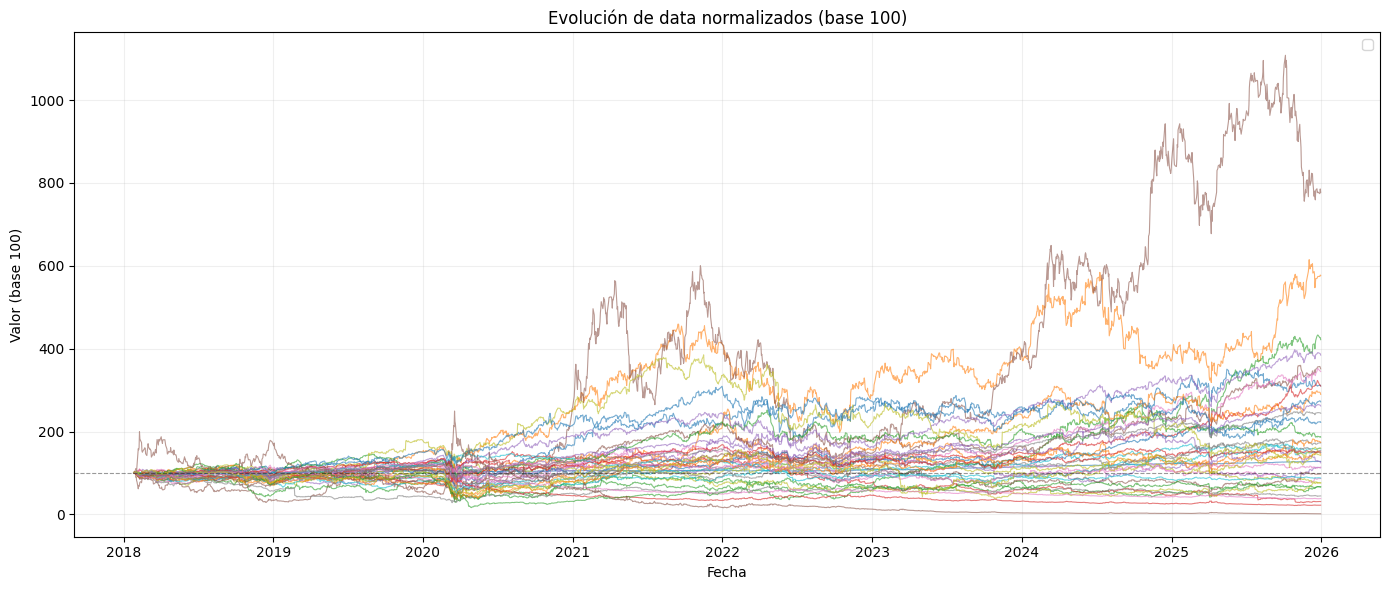

In [29]:
data_norm = data / data.iloc[0] * 100

plt.figure(figsize=(14, 6))

for ticker in data_norm.columns:
    plt.plot(data_norm.index, data_norm[ticker],
             linewidth=0.8, alpha=0.6)

plt.axhline(100, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
plt.title('Evolución de data normalizados (base 100)')
plt.ylabel('Valor (base 100)')
plt.xlabel('Fecha')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

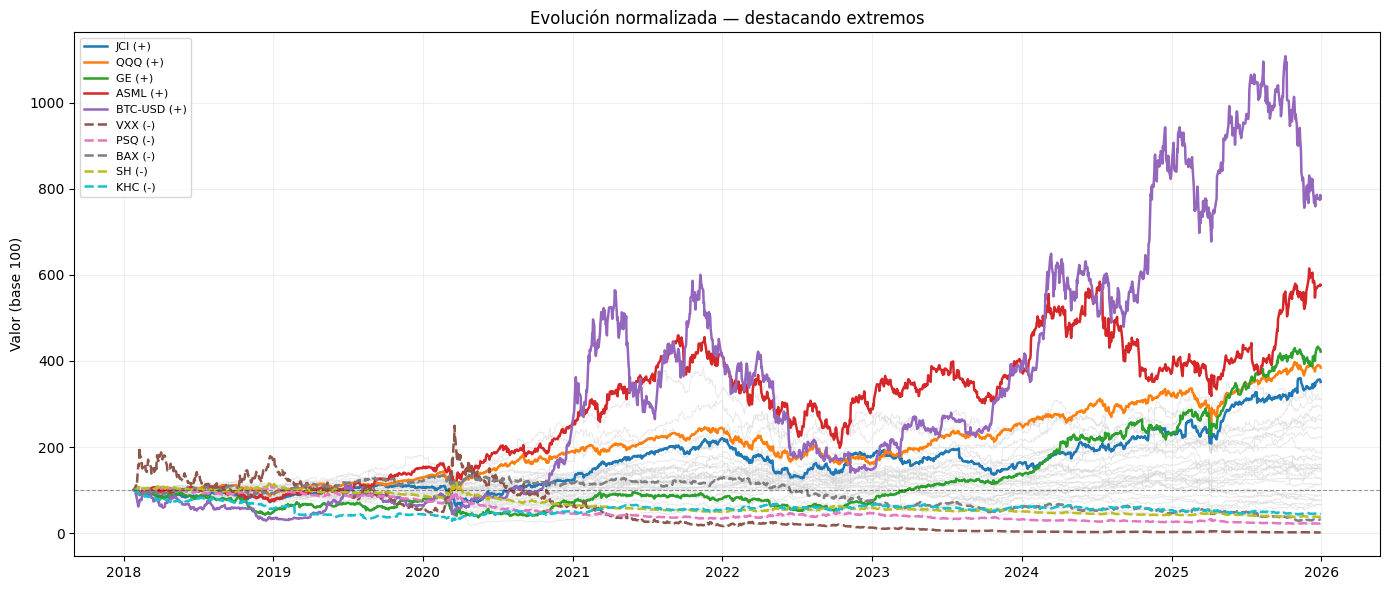

In [33]:
# Valor final de cada activo para identificar extremos
valor_final = data_norm.iloc[-1].sort_values()
top_5    = valor_final.tail(5).index   # los 5 mejores
bottom_5 = valor_final.head(5).index  # los 5 peores

plt.figure(figsize=(14, 6))

# Fondo: todos los activos en gris tenue
for ticker in data_norm.columns:
    plt.plot(data_norm.index, data_norm[ticker],
             color='lightgray', linewidth=0.7, alpha=0.5)

# Encima: los mejores en verde, los peores en rojo
for ticker in top_5:
    plt.plot(data_norm.index, data_norm[ticker],
             linewidth=1.8, label=f'{ticker} (+)')

for ticker in bottom_5:
    plt.plot(data_norm.index, data_norm[ticker],
             linewidth=1.8, linestyle='--', label=f'{ticker} (-)')

plt.axhline(100, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
plt.title('Evolución normalizada — destacando extremos')
plt.ylabel('Valor (base 100)')
plt.legend(fontsize=8, loc='upper left')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

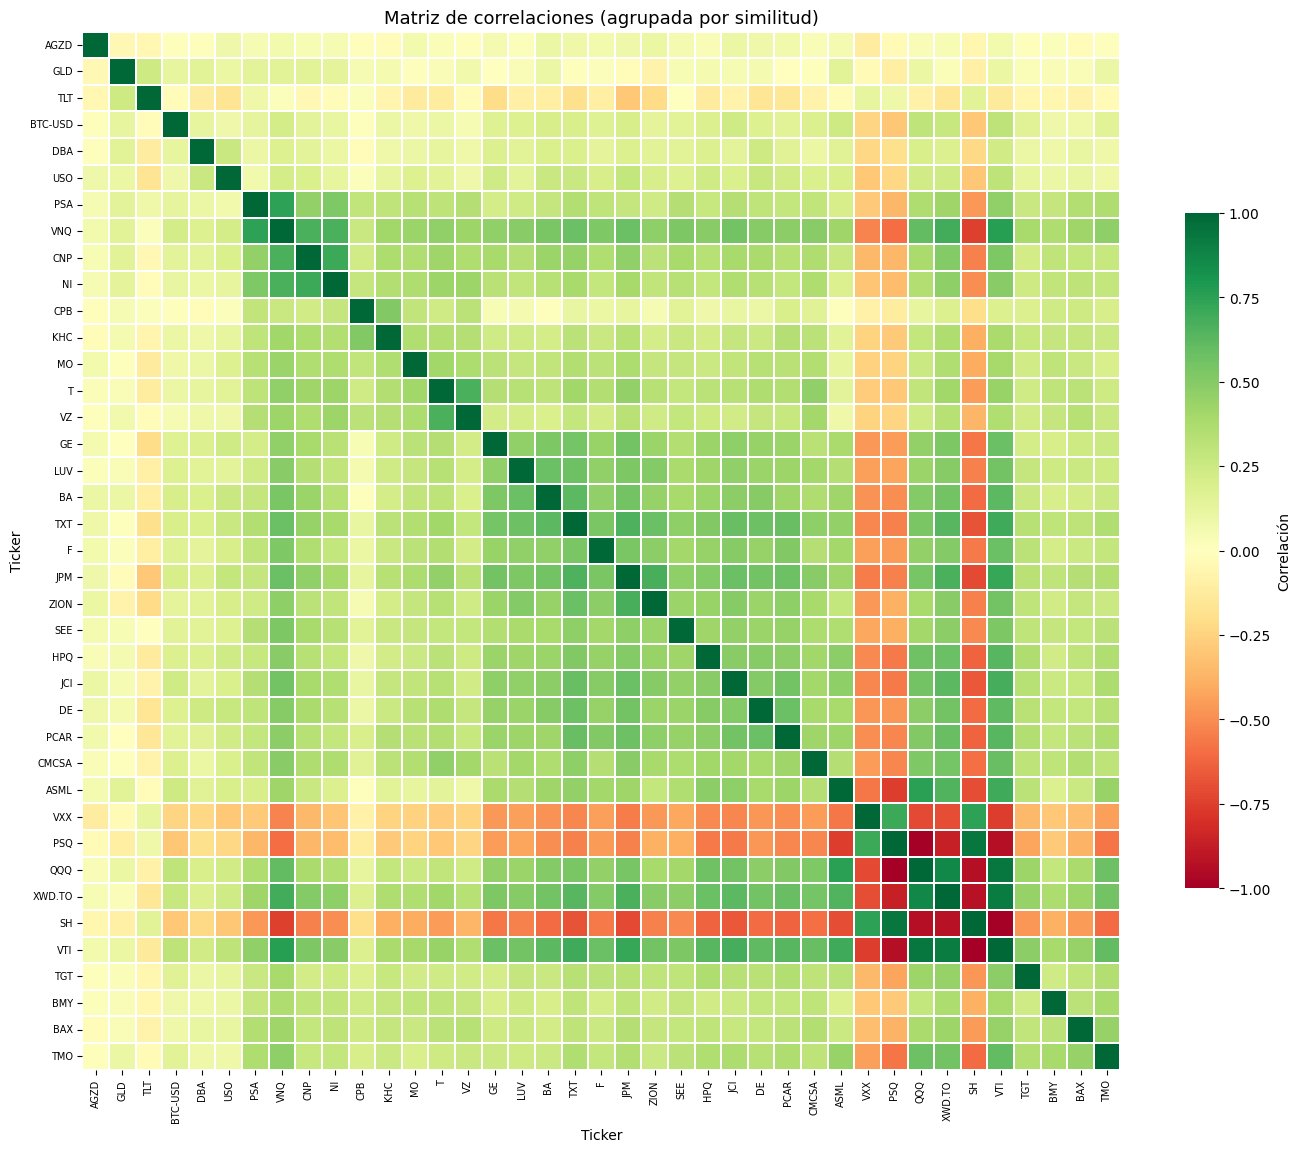

In [35]:
# ============================================================
# GRÁFICO 2 — Heatmap de correlaciones con clustering
# ============================================================

import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

corr = ret_data.corr()

# Reordenar la matriz por similitud (clustering jerárquico)
# Esto agrupa automáticamente los activos correlacionados entre sí
distancia    = 1 - corr.abs()          # convertir correlación en distancia
enlace       = linkage(squareform(distancia), method='ward')
orden        = dendrogram(enlace, no_plot=True)['leaves']
corr_ordenada = corr.iloc[orden, orden]  # reordenar filas y columnas

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_ordenada,
    cmap='RdYlGn',      # rojo=correlación negativa, verde=positiva
    center=0,
    vmin=-1, vmax=1,
    annot=False,         # con 50 activos los números no caben
    square=True,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'shrink': 0.6, 'label': 'Correlación'}
)
plt.title('Matriz de correlaciones (agrupada por similitud)', fontsize=13)
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7, rotation=0)
plt.tight_layout()
plt.show()

In [39]:
from scipy.cluster.hierarchy import fcluster

# Definir cuántos clusters quieres (apunta a 8-12 para 50 activos)
n_clusters  = 10
etiquetas   = fcluster(enlace, n_clusters, criterion='maxclust')
cluster_df  = pd.DataFrame({'activo': corr.columns, 'cluster': etiquetas})

# Para cada cluster, elegir el activo con mejor Sharpe
sharpes = (ret_data.mean() * 252 - rf) / (ret_data.std() * np.sqrt(252))

representantes = []
for c in range(1, n_clusters + 1):
    activos_cluster = cluster_df[cluster_df['cluster'] == c]['activo'].tolist()
    mejor = sharpes[activos_cluster].idxmax()
    representantes.append(mejor)
    print(f"Cluster {c}: {activos_cluster} → representante: {mejor}")

print("\nActivos preseleccionados:", representantes)
# Estos son los 10 activos que entran en la optimización
returns_seleccionados = ret_data[representantes]

Cluster 1: ['GLD', 'TLT'] → representante: GLD
Cluster 2: ['DBA', 'USO'] → representante: DBA
Cluster 3: ['BTC-USD'] → representante: BTC-USD
Cluster 4: ['AGZD'] → representante: AGZD
Cluster 5: ['CNP', 'NI', 'PSA', 'VNQ'] → representante: NI
Cluster 6: ['CPB', 'KHC'] → representante: CPB
Cluster 7: ['MO', 'T', 'VZ'] → representante: T
Cluster 8: ['BA', 'DE', 'F', 'GE', 'HPQ', 'JCI', 'JPM', 'LUV', 'PCAR', 'SEE', 'TXT', 'ZION'] → representante: JCI
Cluster 9: ['ASML', 'CMCSA', 'PSQ', 'QQQ', 'SH', 'VTI', 'VXX', 'XWD.TO'] → representante: QQQ
Cluster 10: ['BAX', 'BMY', 'TGT', 'TMO'] → representante: TMO

Activos preseleccionados: ['GLD', 'DBA', 'BTC-USD', 'AGZD', 'NI', 'CPB', 'T', 'JCI', 'QQQ', 'TMO']


Text(0, 0.5, 'Log Return')

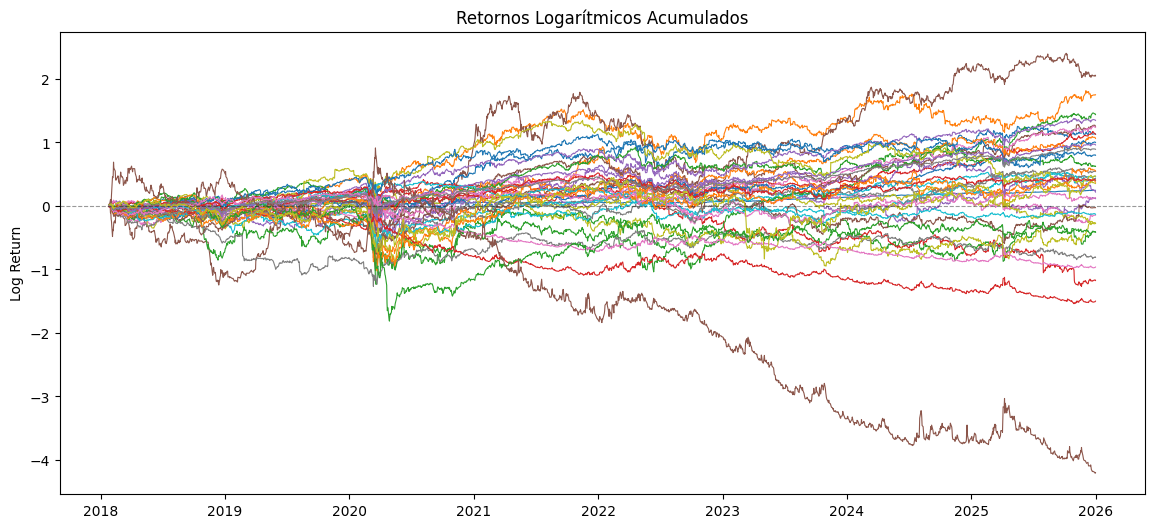

In [31]:
import numpy as np

# Calcular retornos logarítmicos y luego acumularlos (suma)
log_ret_acum = np.log(data / data.shift(1)).cumsum()

plt.figure(figsize=(14, 6))
for ticker in log_ret_acum.columns:
    plt.plot(log_ret_acum.index, log_ret_acum[ticker], linewidth=0.8)

plt.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
plt.title('Retornos Logarítmicos Acumulados')
plt.ylabel('Log Return')
# ... resto del formato

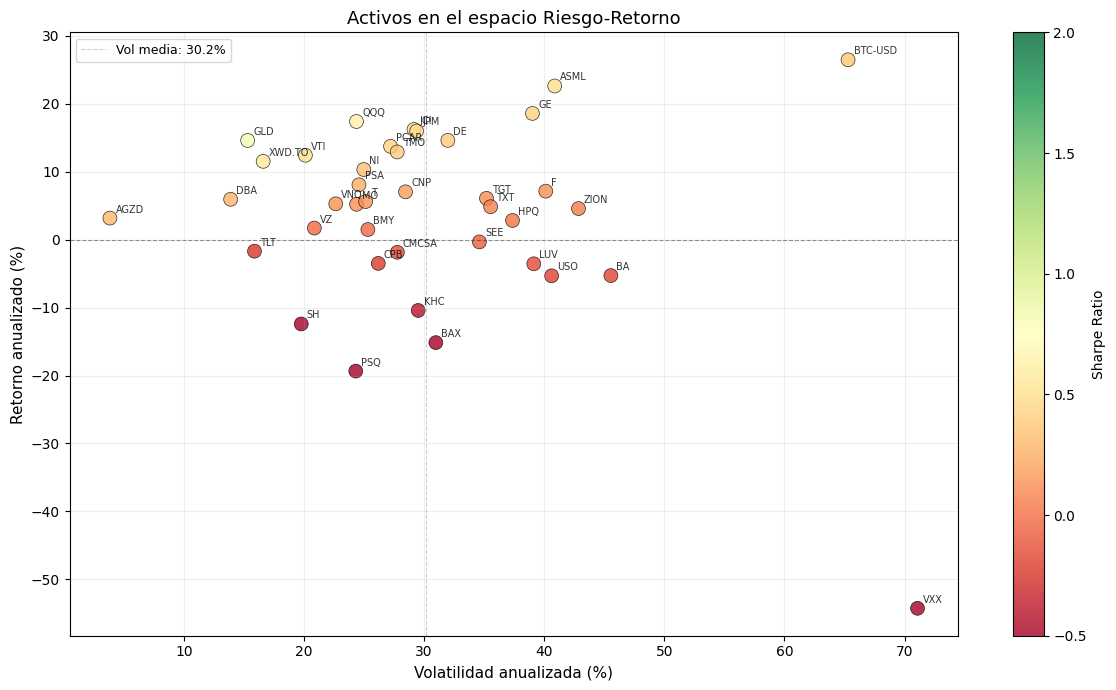

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# Calcular las tres métricas necesarias
RF = 0.02

retorno_anual = ret_data.mean() * 252
volatilidad   = ret_data.std() * np.sqrt(252)
sharpe        = (retorno_anual - RF) / volatilidad


fig, ax = plt.subplots(figsize=(12, 7))

# El scatter: cada punto es un activo
scatter = ax.scatter(
    volatilidad * 100,       # eje X: volatilidad en %
    retorno_anual * 100,     # eje Y: retorno en %
    c=sharpe,                # color según Sharpe
    cmap='RdYlGn',           # rojo=malo, amarillo=medio, verde=bueno
    s=100,                   # tamaño del punto
    alpha=0.8,
    edgecolors='black',
    linewidth=0.5,
    vmin=-0.5, vmax=2.0      # rango del color (ajustar según tus datos)
)

# Barra de color a la derecha
plt.colorbar(scatter, ax=ax, label='Sharpe Ratio')

# Etiquetar cada punto con el nombre del activo
for ticker in ret_data.columns:
    ax.annotate(
        ticker,
        xy=(volatilidad[ticker]*100, retorno_anual[ticker]*100),
        xytext=(4, 4),                    # desplazamiento del texto
        textcoords='offset points',
        fontsize=7,
        alpha=0.8
    )

# Línea horizontal en retorno = 0
ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.4)

# Línea vertical en la volatilidad media (referencia)
ax.axvline(volatilidad.mean()*100, color='gray', linestyle='--',
           linewidth=0.8, alpha=0.4, label=f'Vol media: {volatilidad.mean()*100:.1f}%')

ax.set_xlabel('Volatilidad anualizada (%)', fontsize=11)
ax.set_ylabel('Retorno anualizado (%)',     fontsize=11)
ax.set_title('Activos en el espacio Riesgo-Retorno', fontsize=13)
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

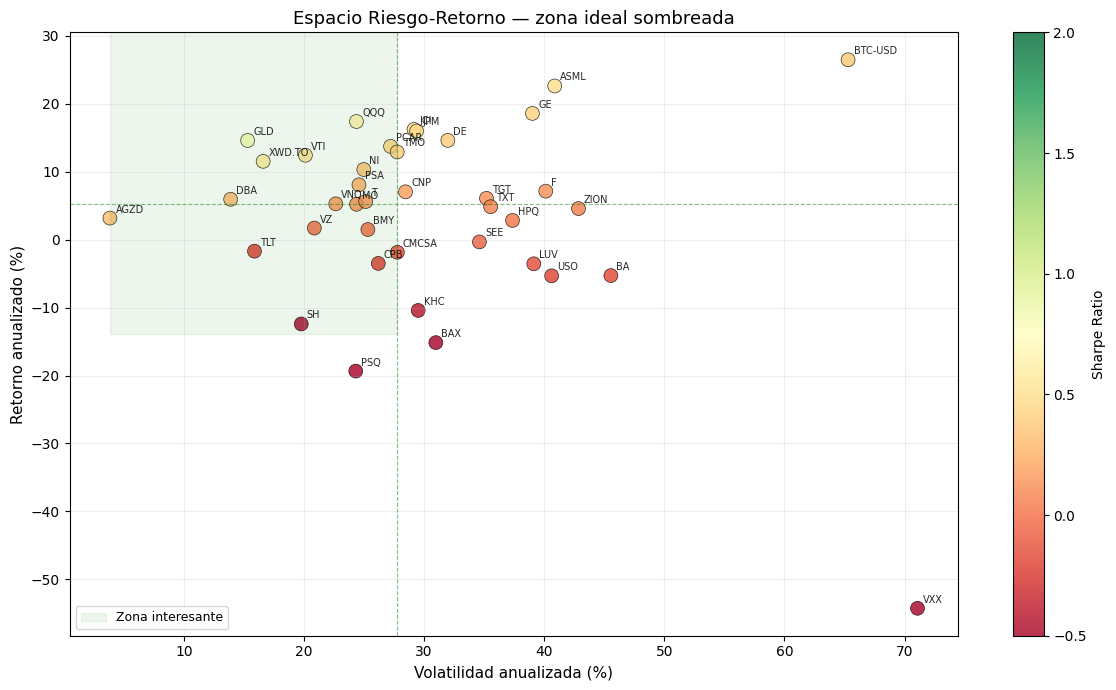


Activos en la zona ideal (10):
Ticker
GLD       0.823
QQQ       0.632
XWD.TO    0.574
VTI       0.518
PCAR      0.431
TMO       0.393
NI        0.333
DBA       0.284
PSA       0.247
T         0.143
dtype: float64


In [54]:
# Umbrales para delimitar la "zona interesante"
vol_umbral = volatilidad.median() * 100       # por debajo de la mediana de vol
ret_umbral = retorno_anual.median() * 100     # por encima de la mediana de retorno

fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(
    volatilidad * 100,
    retorno_anual * 100,
    c=sharpe,
    cmap='RdYlGn',
    s=100, alpha=0.8,
    edgecolors='black', linewidth=0.5,
    vmin=-0.5, vmax=2.0
)
plt.colorbar(scatter, ax=ax, label='Sharpe Ratio')

# Sombrear la zona interesante (esquina superior izquierda)
ax.axvspan(
    volatilidad.min()*100, vol_umbral,   # desde vol mínima hasta la mediana
    ymin=0.5, ymax=1.0,                  # mitad superior del gráfico
    alpha=0.07, color='green',
    label='Zona interesante'
)

# Las dos líneas de referencia
ax.axhline(ret_umbral, color='green', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(vol_umbral, color='green', linestyle='--', linewidth=0.8, alpha=0.5)

# Etiquetas
for ticker in ret_data.columns:
    ax.annotate(
        ticker,
        xy=(volatilidad[ticker]*100, retorno_anual[ticker]*100),
        xytext=(4, 4),
        textcoords='offset points',
        fontsize=7, alpha=0.85
    )

ax.set_xlabel('Volatilidad anualizada (%)', fontsize=11)
ax.set_ylabel('Retorno anualizado (%)',     fontsize=11)
ax.set_title('Espacio Riesgo-Retorno — zona ideal sombreada', fontsize=13)
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# Imprimir los activos que caen dentro de la zona sombreada
zona_ideal = [
    t for t in ret_data.columns
    if volatilidad[t]*100 < vol_umbral and retorno_anual[t]*100 > ret_umbral
]
print(f"\nActivos en la zona ideal ({len(zona_ideal)}):")
print(sharpe[zona_ideal].sort_values(ascending=False).round(3))